# PSE-823: Advanced Process Dynamics and Control
## Lecture 3 -- First-Order Systems, by Simulation
### (Coughanowr & LeBlanc, Ch. 4-6)

Date: __________

## From today: script-first

- Each idea arrives as a **question and a script**, not a derivation.
- You **predict on paper** first; then we run it.
- We **read the output** together; the algebra then explains it.
- Full derivations: the companion notebook (`Derivations`).
- Open the Colab link from the course site to run along.

Pitch: the book is unchanged -- same chapters, same examples, same numbers.
What changes is the order of operations. Previously: derive, then plot.
Now: simulate, observe, then derive to explain what we saw.
Say explicitly: the derivations are still examinable; they are in the
companion notebook and in the book. Laptops/Colab optional in class.

## Agenda

**Part A** -- The first-order transfer function, simulated (Ch. 4)

**Part B** -- Reading $\tau$ from data (Ch. 4, Prob. 4.6)

**Part C** -- The nonlinear tank and linearization (Ch. 5)

**Part D** -- Tanks in series: interaction and transfer lag (Ch. 6)

Tools: `numpy`, `scipy`, `python-control`, `matplotlib`

### Setup (run once)

In [1]:
# Colab only:  !pip install control
import numpy as np
import matplotlib.pyplot as plt
import control as ct
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit
plt.rcParams.update({"font.size": 15})

## Part A
### The First-Order Transfer Function, Simulated

(Coughanowr & LeBlanc, Ch. 4)
<!-- source: coughanowr-ch4 -->

### Concept -- a callback to Lecture 2

Mixing tank, by hand: transform, solve, invert (Eq. 2.2)

$$5\frac{dC_a}{dt}+C_a=2,\quad C_a(0)=3\;\Rightarrow\;C_a(t)=2+e^{-t/5}$$

Today: let the computer **integrate the ODE directly** and check it
against the hand result.

In [2]:
# Lecture 2 callback: 5 dCa/dt + Ca = 2, Ca(0) = 3
def mixing(t, Ca):
    return [(2 - Ca[0]) / 5]

sol = solve_ivp(mixing, [0, 25], [3.0], dense_output=True)
t = np.linspace(0, 25, 200)
err = np.abs(sol.sol(t)[0] - (2 + np.exp(-t / 5)))
print(f"max |numerical - exact| = {err.max():.1e} g/L")

max |numerical - exact| = 1.1e-03 g/L


Expect an error of order 1e-3 g/L with the default tolerances (RK45,
rtol=1e-3). Point: numerical is not exact, but the error is controlled --
rerun with rtol=1e-8 and it drops by orders of magnitude.
This one cell is the whole pivot: no transform, no partial fractions,
same answer. From here on we use both and let each check the other.

### Concept -- the thermometer (Sec. 4.1)

$$hA(x-y)=mC\frac{dy}{dt}\;\xrightarrow{\text{deviation vars}}\;
\frac{Y(s)}{X(s)}=\frac{1}{\tau s+1},\quad \tau=\frac{mC}{hA}$$

Standard form: $K_p/(\tau s+1)$ -- gain $K_p$, time constant $\tau$.

**FIGURE PLACEHOLDER -- Fig. 4-1a: cross-section of thermometer bulb**

Five-step recipe (Sec. 4.1): balance -> linearize if needed -> deviation
variables -> Laplace -> ratio output/input. Deviation variables make
initial conditions zero, which is why Y(s)/X(s) exists at all.
Ex. 4.1: Y/X = 2/(s + 1/3) = 6/(3s + 1), so tau = 3 and Kp = 6.
Always rearrange to standard form (1 in the denominator) before reading
off tau and Kp.

### Predict (1 min, on paper)

**Example 4.2.** Thermometer, $\tau = 0.1$ min, at 90 F.
At $t=0$ it goes into a 100 F bath.

- Sketch the reading versus time.
- Roughly how many time constants until it reads **98 F**?

### Run -- step response with `python-control`

In [3]:
tau = 0.1                            # min, Example 4.2
G = ct.tf([1], [tau, 1])             # Y/X = 1/(tau s + 1)
t = np.linspace(0, 0.6, 601)
resp = ct.step_response(10 * G, t)   # bath steps 90 -> 100 F
y = 90 + resp.outputs                # back to absolute F
t98 = t[np.argmax(y >= 98)]
print(f"reads 98 F at t = {t98:.3f} min = {t98/tau:.2f} tau")

reads 98 F at t = 0.161 min = 1.61 tau


### Effect of $\tau$ on the step response (cf. Fig. 4-13)

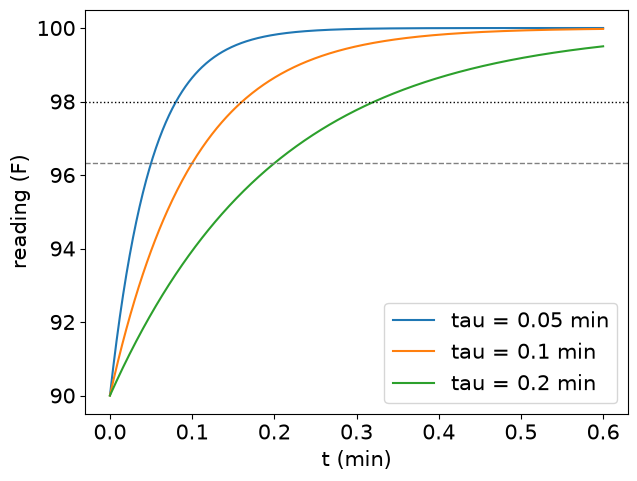

In [4]:
fig, ax = plt.subplots(figsize=(7, 5.25))
for tau in [0.05, 0.1, 0.2]:
    r = ct.step_response(10 * ct.tf([1], [tau, 1]), t)
    ax.plot(t, 90 + r.outputs, label=f"tau = {tau} min")
ax.axhline(90 + 6.32, ls="--", c="gray", lw=1)
ax.axhline(98, ls=":", c="k", lw=1)
ax.set(xlabel="t (min)", ylabel="reading (F)")
ax.legend(); plt.show()

Dashed: 63.2% of the change. Dotted: 98 F. Larger $\tau$, slower reading.

### Read the output

The script found $t = 0.161$ min without inverting anything.

The book's route (Eq. 4.15): $Y=A(1-e^{-t/\tau})$, so
$8 = 10(1-e^{-t/0.1})\Rightarrow t = 0.161$ min.

Rules worth keeping: 63.2% at $t=\tau$; 95% at $3\tau$; 98% at $4\tau$.

### Predict -- sinusoidal input

**Example 4.3.** Same thermometer ($\tau=0.1$ min) in a bath that
oscillates $\pm 2$ F about 100 F at $\omega = 20$ rad/min.

- Does the thermometer show the full $\pm 2$ F swing?
- Does its peak coincide with the bath's peak?

In [5]:
tau, w, A = 0.1, 20.0, 2.0           # Example 4.3
G = ct.tf([1], [tau, 1])
t = np.linspace(0, 1.0, 2001)
X = A * np.sin(w * t)                # bath deviation, F
Y = ct.forced_response(G, t, X).outputs
late = t > 0.5                       # after ~5 tau
print(f"output amplitude: {Y[late].max():.3f} F  (input {A} F)")

output amplitude: 0.895 F  (input 2.0 F)


### Bath versus thermometer (cf. Fig. 4-18)

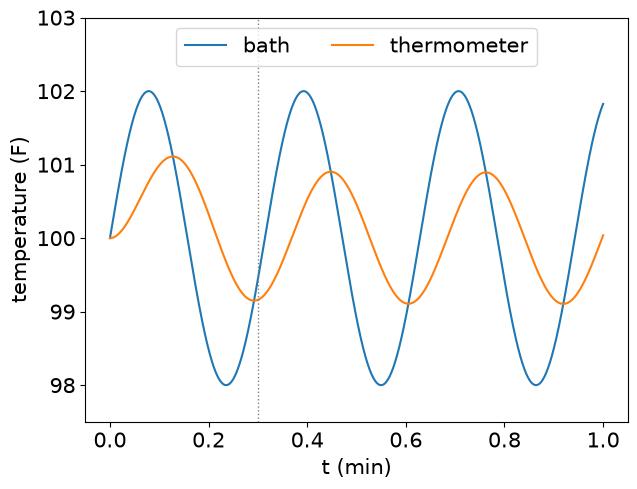

In [6]:
fig, ax = plt.subplots(figsize=(7, 5.25))
ax.plot(t, 100 + X, label="bath")
ax.plot(t, 100 + Y, label="thermometer")
ax.axvline(0.3, ls=":", c="gray", lw=1)     # ~3 tau
ax.set(xlabel="t (min)", ylabel="temperature (F)", ylim=(97.5, 103))
ax.legend(loc="upper center", ncol=2); plt.show()

Left of the dotted line: transient. Right: attenuated, lagging sine.

### Read the output

Ultimate response (Eq. 4.28): same frequency, attenuated, lagging.

$$\frac{\hat{Y}}{A}=\frac{1}{\sqrt{1+\omega^2\tau^2}}=0.894,
\qquad \phi=-\tan^{-1}(\omega\tau)=-63.4^\circ$$

Lag in time: $\phi/\omega = 0.055$ min. The book rounds to 0.896 and 63.5.
This is **frequency response** in miniature -- Ch. 15.

### Your Turn (10 min)

**Probs. 4.9-4.10.** Thermometer, $\tau = 1$ min, reads 50 C.
At $t=0$ it goes into a 100 C bath; at $t=1.5$ min it is moved
to a 75 C bath.

1. By hand: the reading at $t=1.2$ min.
2. By hand: the **maximum** reading, and the reading at $t=20$ min.
3. Then: edit the step-response cell to check (1).

(1) y = 100 - 50 e^{-1.2} = 84.94 C.
(2) At t = 1.5: y = 100 - 50 e^{-1.5} = 88.84 C. After the move the
    reading decays toward 75: y = 75 + 13.84 e^{-(t-1.5)}. So the maximum
    is 88.84 C, at the moment of transfer; at t = 20 min, y = 75.00 C.
(3) tau = 1, t up to 3 min, 50*G, y = 50 + outputs.
Common slip: thinking the reading keeps rising after the move (it was
below 100, above 75 -> falls immediately). Full piecewise simulation
with forced_response is in the Derivations notebook.

### Check -- cold-call

In Example 4.3, **halve** $\tau$.

Does the lag *in minutes* between bath and thermometer peaks
go up or down? Answer from the formula -- then we rerun the cell.

phi = atan(w tau) = atan(1) = 45 deg; lag = phi/w = 0.785/20 = 0.039 min,
down from 0.055 min. Smaller tau = faster sensor = less attenuation and
less lag. Rerun the Part A sinusoid cell with tau = 0.05 to confirm.

## Part B
### Reading $\tau$ from Data

(Coughanowr & LeBlanc, Ch. 4, Prob. 4.6)
<!-- source: coughanowr-ch4 -->

### Concept

So far $\tau = mC/hA$ came from physics. In practice $h$ is unknown:
you **measure** the response and infer $\tau$.

**Prob. 4.6.** Thermometer at 75 F plunged into a 400 F oil bath.
The book asks for two independent estimates of $\tau$.

First time in this course a model is **learned from data**.

In [7]:
# Problem 4.6: 75 F room -> 400 F oil bath at t = 0
t_d = np.array([0, 1, 2.5, 5, 8, 10, 15, 30])           # s
y_d = np.array([75, 107, 140, 205, 244, 282, 328, 385])  # F
frac = (y_d - 75) / (400 - 75)                           # Y/A
for ti, f in zip(t_d, frac):
    print(f"t = {ti:5.1f} s    Y/A = {f:.3f}")

t =   0.0 s    Y/A = 0.000
t =   1.0 s    Y/A = 0.098
t =   2.5 s    Y/A = 0.200
t =   5.0 s    Y/A = 0.400
t =   8.0 s    Y/A = 0.520
t =  10.0 s    Y/A = 0.637
t =  15.0 s    Y/A = 0.778
t =  30.0 s    Y/A = 0.954


### Your Turn (8 min) -- two estimates by hand

1. **63.2% crossing:** interpolate the table for $Y/A = 0.632$.
2. **Log-linearize:** $\ln(1-Y/A) = -t/\tau$.
   Use the points at $t=5$ and $t=15$ s to get the slope.

Do your two estimates agree?

(1) Y/A = 0.520 at 8 s, 0.637 at 10 s -> t = 8 + 2(0.632-0.520)/(0.117)
    = 9.9 s.
(2) ln(1-0.400) = -0.511 ; ln(1-0.778) = -1.504.
    slope = (-1.504 + 0.511)/10 = -0.0993 /s -> tau = 10.1 s.
Both about 10 s. Pointwise, each data point implies a different tau
(9.6 to 11.2 s) -- that scatter is the measurement noise. Which estimate
to trust? That question motivates the next cell.

### Run -- least squares with `curve_fit`

In [8]:
def first_order(t, tau):
    return 75 + 325 * (1 - np.exp(-t / tau))

popt, pcov = curve_fit(first_order, t_d, y_d, p0=[5.0])
tau_fit, tau_se = popt[0], np.sqrt(pcov[0, 0])
print(f"tau = {tau_fit:.2f} +/- {tau_se:.2f} s")
res = y_d - first_order(t_d, tau_fit)
print("residuals (F):", np.round(res, 1))

tau = 10.19 +/- 0.19 s
residuals (F): [ 0.   1.6 -5.7  3.9 -7.8  3.8  2.5  2.1]


### Data and fitted first-order model

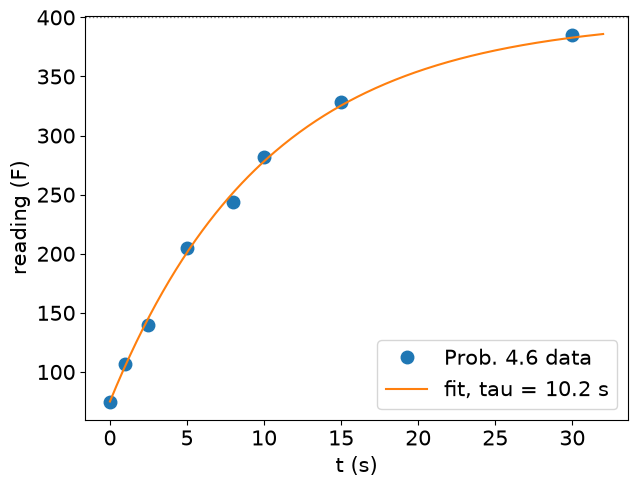

In [9]:
tt = np.linspace(0, 32, 300)
fig, ax = plt.subplots(figsize=(7, 5.25))
ax.plot(t_d, y_d, "o", ms=9, label="Prob. 4.6 data")
ax.plot(tt, first_order(tt, tau_fit),
        label=f"fit, tau = {tau_fit:.1f} s")
ax.axhline(400, ls=":", c="gray", lw=1)
ax.set(xlabel="t (s)", ylabel="reading (F)")
ax.legend(loc="lower right"); plt.show()

One parameter, all eight points used at once, with an error bar.

### Read the output

`curve_fit` minimizes $\sum_i (y_i-\hat y_i)^2$ --
the **same objective** as linear regression in machine learning.

- Here physics fixes the model's form; only $\tau$ is learned.
- Residuals of a few F, no clear trend: first order is adequate.
- The $\pm$ uncertainty is information no single hand estimate gives.

Returns at scale in Ch. 18 (process identification).

Expect tau = 10.19 +/- 0.19 s. Residuals within about +/- 8 F and
alternating in sign -- no systematic curvature, so no evidence for a
second lag. If you let the gain float too (fit K and tau), K = 330 F,
close to the known 325 F: a sanity check on the data.
Framing for the class: ML is this same move with a far more flexible
model form -- which buys fit and costs interpretability and
extrapolation. We will hold that trade-off up to the light in L10-L11.

### Check -- think-pair-share

The fit gives $\tau \approx 10$ s **in oil**.

Would you use $\tau = 10$ s for the same thermometer **in air**?
What does your answer say about *any* model fitted from data?

No. tau = mC/hA and h in air is far lower (the book's note under Ex. 4.2;
Prob. 4.8 takes h_air = h_oil/5, so tau_air ~ 50 s).
General lesson: a fitted model is only valid for conditions represented
in the data. This is the extrapolation problem that returns, much
sharper, with ML models in L10-L11.

## Part C
### The Nonlinear Tank and Linearization

(Coughanowr & LeBlanc, Ch. 5)
<!-- source: coughanowr-ch5 -->

### Concept -- one transfer function, many processes (Sec. 5.1)

Tank with linear outlet $q_o = h/R$: $\;A\dfrac{dh}{dt} = q - \dfrac{h}{R}
\;\Rightarrow\; \dfrac{H(s)}{Q(s)}=\dfrac{R}{\tau s+1},\;\tau=AR$

Thermometer $mC/hA$, tank $AR$, mixing $V/q$, heater $\rho V/w$:
**same form, same code.**

**FIGURE PLACEHOLDER -- Fig. 5-1: liquid-level system**

### Concept -- a real valve is not linear (Sec. 5.2)

Turbulent outlet $q_o = C\sqrt{h}$: $\;A\dfrac{dh}{dt} = q - C\sqrt{h}$
-- no Laplace transform exists.

Taylor about $h_s$ (Eq. 5.33): $\;R_1 = \dfrac{2\sqrt{h_s}}{C},
\quad \tau = R_1 A$

Book example: $A=3$ ft$^2$, $h_s=4$ ft at $q_s=16$ cfm $\Rightarrow$
$C=8$, $R_1=0.5$ ft/cfm, $\tau=1.5$ min.

**FIGURE PLACEHOLDER -- Fig. 5-8: nonlinear resistance and tangent line**

### Predict (1 min)

Step the inflow **16 to 20 cfm**.

The linear model says $h \to 4 + 0.5(4) = 6$ ft.

Does the real (square-root) tank settle **above, below, or at** 6 ft?

### Run -- nonlinear ODE versus linear transfer function

In [10]:
A, C, hs, qs = 3.0, 8.0, 4.0, 16.0   # Sec. 5.2 example
def tank(t, h, q):
    return [(q - C * np.sqrt(h[0])) / A]

R1 = 2 * np.sqrt(hs) / C             # linearized resistance
G_lin = ct.tf([R1], [A * R1, 1])     # H/Q = R1/(tau s + 1)
t = np.linspace(0, 10, 500)
dq = 4.0                             # 16 -> 20 cfm
h_nl = solve_ivp(tank, [0, 10], [hs], args=(qs + dq,),
                 t_eval=t).y[0]
h_lin = hs + ct.step_response(dq * G_lin, t).outputs
print(f"final h: nonlinear {h_nl[-1]:.2f}, linear {h_lin[-1]:.2f} ft")

final h: nonlinear 6.24, linear 6.00 ft


### Nonlinear versus linearized (cf. Fig. 5-9)

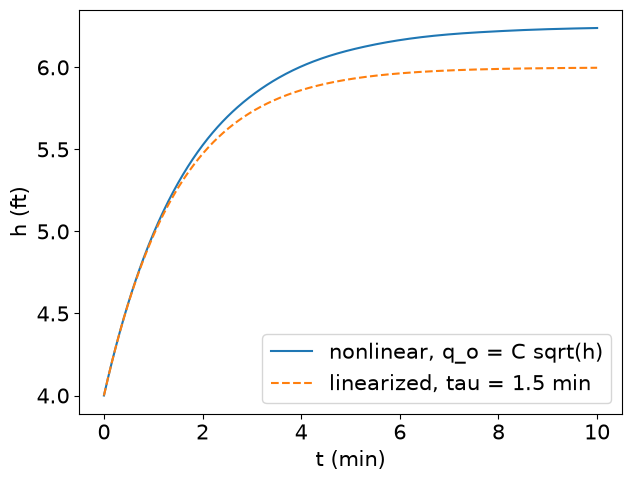

In [11]:
fig, ax = plt.subplots(figsize=(7, 5.25))
ax.plot(t, h_nl, label="nonlinear, q_o = C sqrt(h)")
ax.plot(t, h_lin, "--", label="linearized, tau = 1.5 min")
ax.set(xlabel="t (min)", ylabel="h (ft)")
ax.legend(loc="lower right"); plt.show()

Same start, same early slope; they part as $h$ moves away from $h_s$.

### Run -- where is the linear model good enough?

In [12]:
q = np.linspace(4, 32, 281)          # candidate inflows, cfm
h_true = (q / C) ** 2                # nonlinear steady state
h_tan = hs + R1 * (q - qs)           # linearized steady state
err = 100 * (h_tan - h_true) / h_true
ok = np.abs(err) < 5
print(f"within 5%: q from {q[ok].min():.1f} "
      f"to {q[ok].max():.1f} cfm")

within 5%: q from 13.1 to 20.6 cfm


### Steady states: the curve and its tangent

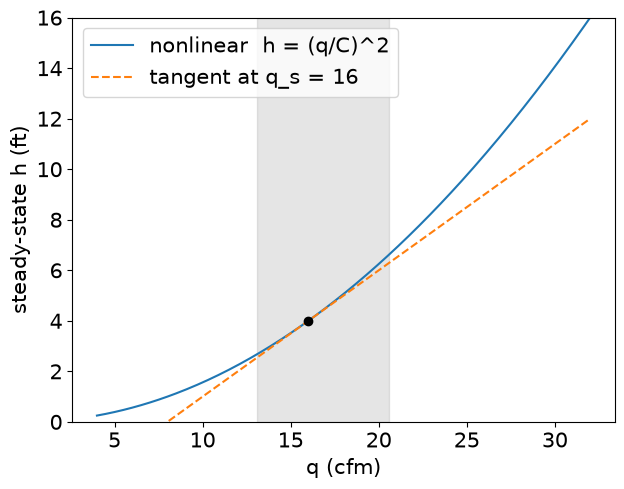

In [13]:
fig, ax = plt.subplots(figsize=(7, 5.25))
ax.plot(q, h_true, label="nonlinear  h = (q/C)^2")
ax.plot(q, h_tan, "--", label="tangent at q_s = 16")
ax.axvspan(q[ok].min(), q[ok].max(), color="gray", alpha=0.2)
ax.plot(qs, hs, "ko")
ax.set(xlabel="q (cfm)", ylabel="steady-state h (ft)", ylim=(0, 16))
ax.legend(loc="upper left"); plt.show()

Shaded: the validity window (error under 5%). Outside it, the tangent drifts.

### Read the output

- Exact at $h_s$, good nearby, wrong far away -- a **validity window**.
- The book: adequate when a controller holds $h$ near $h_s$ (Sec. 5.2).
- Every model -- transfer function, regression, neural net --
  has a window. The real question: **do you know where its edges are?**

Window algebra (Derivations notebook): with x = q/qs, relative error
= -(x-1)^2/x^2, so |err| < 5% for x in [0.817, 1.288], i.e. q in
[13.1, 20.6] cfm. The book's own +4 cfm step (to 20) sits right at the
edge -- which is why Fig. 5-9 shows a visible but modest gap.
Bridge: this is the same question we will ask of ML surrogates in L11.

### Your Turn (8 min)

**Prob. 5.2.** Tank with $A = 3$ ft$^2$ and valve $q = 8\sqrt{h}$.

1. By hand: $\tau$ at an operating level of (a) 3 ft, (b) 9 ft.
2. Then: set `hs` (and `qs = 8*np.sqrt(hs)`) in the Part C cell,
   use a small `dq`, and confirm the two curves overlap.

tau = R1 A = 2 A sqrt(h_s)/C.
(a) 2(3)(1.732)/8 = 1.30 min.  (b) 2(3)(3)/8 = 2.25 min.
Same tank, same valve, different tau: the dynamics depend on where
you operate. Consequence for later: a controller tuned at 3 ft is
tuned for a different process than the one at 9 ft (gain scheduling,
nonlinear control, L14). Slip: using C = 8 with h instead of sqrt(h).

### Check -- poll

Now step the inflow **down**, 16 to 12 cfm.
The linear model's final level is:

**A)** too high  **B)** too low  **C)** exactly right

B, too low: linear gives 4 - 0.5(4) = 2.00 ft; true (12/8)^2 = 2.25 ft.
Same side as the +4 step (6.00 vs 6.25). Reason: h = (q/C)^2 is convex,
so the tangent lies below the curve everywhere. Rerun the cell with
dq = -4 to show it.

## Part D
### Tanks in Series: Interaction and Transfer Lag

(Coughanowr & LeBlanc, Ch. 6)
<!-- source: coughanowr-ch6 -->

### Concept

Noninteracting ($q_1 = h_1/R_1$): transfer functions **multiply** (Eq. 6.7)

$$\frac{H_2}{Q}=\frac{R_2}{(\tau_1 s+1)(\tau_2 s+1)}$$

Interacting ($q_1 = (h_1-h_2)/R_1$): they do **not** (Eq. 6.24)

$$\frac{H_2}{Q}=\frac{R_2}{\tau_1\tau_2 s^2+(\tau_1+\tau_2+A_1R_2)s+1}$$

**FIGURE PLACEHOLDER -- Fig. 6-1: (a) noninteracting, (b) interacting tanks**

### Predict (1 min)

Identical tanks and valves, $\tau_1=\tau_2=1$.
Unit step in $q$.

Which $h_2$ rises faster -- **interacting** or **noninteracting**?
Sketch both on one axis.

### Run -- one ODE function, both arrangements

In [14]:
A1, A2, R1, R2 = 1.0, 1.0, 1.0, 1.0   # tau1 = tau2 = 1
def two_tanks(t, h, q, interacting):
    h1, h2 = h
    q1 = (h1 - h2) / R1 if interacting else h1 / R1
    return [(q - q1) / A1, (q1 - h2 / R2) / A2]

t = np.linspace(0, 10, 400)
h2 = {}
for mode in (False, True):            # deviation variables
    s = solve_ivp(two_tanks, [0, 10], [0.0, 0.0],
                  args=(1.0, mode), t_eval=t)
    h2[mode] = s.y[1]

### ODE simulation versus the book's transfer functions

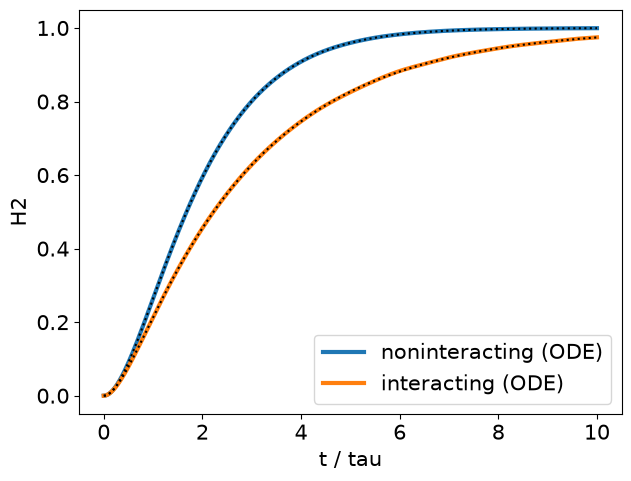

In [15]:
G_non = ct.tf([1], [1, 1]) * ct.tf([1], [1, 1])   # Eq. 6.7
G_int = ct.tf([1], [1, 3, 1])                     # Eq. 6.24
fig, ax = plt.subplots(figsize=(7, 5.25))
ax.plot(t, h2[False], lw=3, label="noninteracting (ODE)")
ax.plot(t, h2[True], lw=3, label="interacting (ODE)")
for G in (G_non, G_int):
    ax.plot(t, ct.step_response(G, t).outputs, "k:")
ax.set(xlabel="t / tau", ylabel="H2")
ax.legend(loc="lower right"); plt.show()

Dotted: Eqs. 6.7 and 6.24. The ODE never saw a transfer function, yet matches both.

### Read the output

- Interaction **slows** the response (cf. Fig. 6-7).
- Physically: rising $h_2$ throttles $q_1$ (the second tank *loads* the first).
- `G_int.poles()` gives $-2.62$ and $-0.38$: effective time constants
  $0.38\tau$ and $2.62\tau$ (Eq. 6.28).
- Two coupled states in one `solve_ivp` call: a **state-space** model, before Ch. 21.

Run G_int.poles() live. The simulation needs no algebra to 'discover'
interaction -- it falls out of writing q1 correctly. The algebra
(Eq. 6.24, full derivation in the companion notebook) is what tells
you *why*: the cross term A1 R2 in the s coefficient.

### More tanks in series (cf. Figs. 6-5, 6-6)

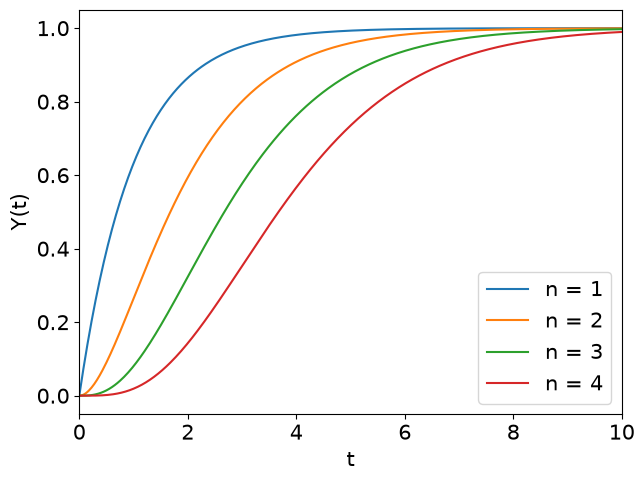

In [16]:
fig, ax = plt.subplots(figsize=(7, 5.25))
G = ct.tf([1], [1])
for n in range(1, 5):
    G = G * ct.tf([1], [1, 1])       # add one tank, tau = 1
    ax.plot(t, ct.step_response(G, t).outputs, label=f"n = {n}")
ax.set(xlabel="t", ylabel="Y(t)", xlim=(0, 10))
ax.legend(loc="lower right"); plt.show()

Transfer lag grows with $n$: from outside, it starts to look like a dead time.

### Your Turn (8 min)

Interacting tanks with $\tau_1=\tau_2=\tau$ and $A_1=A_2$
(so $A_1R_2=\tau$).

1. By hand: show the denominator of Eq. 6.24 becomes
   $\tau^2 s^2 + 3\tau s + 1$.
2. By hand: find its roots, and the two effective time constants.
3. Then: check with `np.roots([1, 3, 1])`.

(1) tau1 tau2 = tau^2 ; tau1 + tau2 + A1 R2 = tau + tau + tau = 3 tau.
(2) s = (-3 +/- sqrt(5)) / (2 tau) = -0.382/tau, -2.618/tau.
    Effective time constants = -1/root = 2.618 tau and 0.382 tau
    (their product is tau^2, their sum 3 tau). Eq. 6.28.
(3) np.roots([1,3,1]) -> [-2.618, -0.382].
Aside for the curious: 2.618 = phi^2, 0.382 = 1/phi^2 (golden ratio).

### Check -- cold-call

Four tanks in series. You only have the **measured** $h_4(t)$.

What is the simplest model you would fit -- and what would
its parameters mean physically?

A first-order-plus-dead-time (FOPDT) model, K e^{-theta s}/(tau s + 1):
theta absorbs the transfer lag of the upstream tanks, tau the dominant
lag, K the gain. It is Part B's curve_fit with one more parameter.
Sets up Ch. 7 (transportation lag, next lecture) and Ch. 18 (process
identification, L10).

### Wrap-up

**Covered:** first-order systems simulated -- step, sinusoid (Ch. 4);
$\tau$ learned from data by least squares (Prob. 4.6);
linearization and its validity window (Ch. 5);
interacting versus noninteracting tanks (Ch. 6).

**Tools:** `solve_ivp`, `ct.tf`, `step_response`, `forced_response`, `curve_fit`

**Next:** Ch. 7 -- second-order systems and transportation lag.
We fit an FOPDT model to today's four-tank curve.

Optional practice (ungraded): Prob. 5.7 gives steady-state level versus
inflow for a real tank. Fit q = K h^n with curve_fit, then linearize the
fitted valve at 300 and 400 gal/min and compare tau. This is Part B +
Part C on real data -- a good warm-up for Assignment 1.